# Political Compass MCQ — primary models


    This notebook uses the released configuration-level MCQ table. One row is
    one sampled prompt configuration after the 62 answer distributions have
    been mapped to an economic and social coordinate. It contains only the four
    Gemma and four Qwen checkpoints used in the paper.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'core.py').exists():
    candidate = Path('tasks/political-compass/analysis').resolve()
    if (candidate / 'core.py').exists():
        ANALYSIS_DIR = candidate
    else:
        candidate = Path.cwd().parent
        if (candidate / 'core.py').exists():
            ANALYSIS_DIR = candidate
        else:
            raise FileNotFoundError('Run this notebook from the repository or analysis directory.')
sys.path.insert(0, str(ANALYSIS_DIR))

from core import (
    GEMMA_MODELS, QWEN_MODELS, PRIMARY_MODELS, IDEOLOGY_ORDER,
    load_mcq_configurations, load_chat_configurations, plot_centroid_grid,
    qwen_think_outcomes, size_label,
)

sns.set_theme(style='whitegrid')

In [2]:
mcq = load_mcq_configurations()
summary = pd.Series({
    'rows': len(mcq),
    'models': mcq['model'].nunique(),
    'quantizations': mcq['quantization'].nunique(),
    'ideologies': mcq['ideology'].nunique(),
    'languages': mcq['language'].nunique(),
    'unique config IDs': mcq['config_id'].nunique(),
})
display(summary.to_frame('value'))
assert len(mcq) == 43_200
assert set(mcq['model']) == set(PRIMARY_MODELS)

,value
rows,43200
models,8
quantizations,3
ideologies,6
languages,14
unique config IDs,14400


## Persona centroids

Each point below is the mean coordinate over all sampled prompt and
quantization configurations for one assigned persona. The plot shows
where the average lands; it does not imply that every configuration or
proposition lands there.

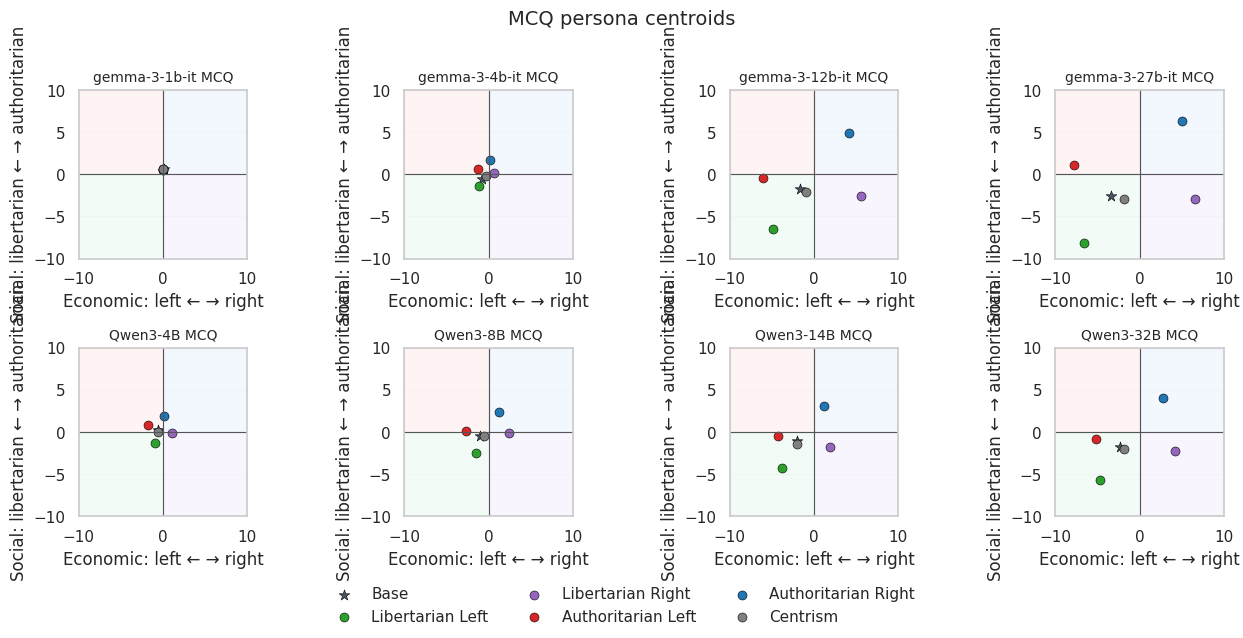

In [3]:
panels = [(f'{model}|mcq', f'{model} MCQ') for model in PRIMARY_MODELS]
plot_frame = mcq.rename(columns={'score_econ': 'economic', 'score_soc': 'social'})
fig = plot_centroid_grid(plot_frame, panels, ncols=4, title='MCQ persona centroids')
plt.show()

## Factor-sensitivity summary

A value is a standard-deviation-sized contribution in compass points
after fitting each ideology condition separately. This is a measurement
of variation associated with the sampled factor, not a universal claim
about a family or checkpoint size.

In [4]:
sensitivity = pd.read_csv(ANALYSIS_DIR / 'data' / 'pct_factor_sensitivity.csv')
display(sensitivity.head(12))

,model,axis,Ideology,Total Variation,Residual Jitter,Response Entropy,quantization_sd,quantization_k,quantization_chi2,quantization_log10p,...,key_type_chi2,key_type_log10p,perm_id_sd,perm_id_k,perm_id_chi2,perm_id_log10p,persona_combo_sd,persona_combo_k,persona_combo_chi2,persona_combo_log10p
0,gemma-3-1b-it,econ,0.022483,1.319516,0.739176,1.085168,0.048521,6,22.639171,-1.509336,...,39.881127,-4.123496,0.090607,6,63.337098,-8.257694,0.072238,5,13.603700,-0.717044
1,gemma-3-4b-it,econ,0.760179,1.628082,1.183750,0.964680,0.122023,6,47.345948,-5.391417,...,35.951066,-3.481600,0.175205,6,111.112222,-17.443090,0.258768,5,144.486516,-25.295495
2,gemma-3-12b-it,econ,4.688741,1.902013,1.427646,0.876679,0.213311,6,115.881399,-18.389139,...,109.401839,-17.104727,0.235034,6,137.207886,-22.659404,0.864405,5,1355.317839,-284.357129
3,gemma-3-27b-it,econ,5.935372,1.865980,1.290094,0.731847,0.136102,6,55.350652,-6.805238,...,35.084900,-3.342993,0.297035,6,264.141324,-48.816080,0.861116,5,1541.228833,-324.506452
4,Qwen3-4B,econ,0.968983,2.004846,1.123198,1.417109,0.160737,6,130.132488,-21.236169,...,53.780289,-6.524193,0.421505,6,681.839559,-137.469102,0.429638,5,564.776778,-114.210370
5,Qwen3-8B,econ,1.861775,2.131105,1.146886,1.461247,0.157061,6,89.189421,-13.149666,...,53.158772,-6.413423,0.330083,6,384.410627,-74.122675,0.624870,5,1204.740394,-251.863921
6,Qwen3-14B,econ,2.547216,2.269249,1.237625,1.551424,0.132997,6,60.877095,-7.806493,...,312.523212,-58.959443,0.487229,6,701.483279,-141.673186,0.735329,5,1312.657686,-275.149069
7,Qwen3-32B,econ,3.865435,2.277038,1.231057,1.458457,0.103618,6,44.539013,-4.908077,...,728.654062,-147.490959,0.280908,6,262.487269,-48.470442,0.770608,5,1490.116824,-313.466207
8,gemma-3-1b-it,soc,0.078182,3.225600,2.751755,0.694339,0.051915,6,1.900409,-0.000198,...,8.477386,-0.126795,1.429236,6,1252.234387,-260.011669,0.276521,5,12.932843,-0.643112
9,gemma-3-4b-it,soc,1.056955,2.726956,2.236713,0.637983,0.168824,6,28.080500,-2.268897,...,31.563824,-2.791796,0.733005,6,544.316291,-108.093833,0.499984,5,168.625131,-30.272278
